C:\Users\Tannis\AppData\Local\Temp\ipykernel_9264\2060102072.py:37: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


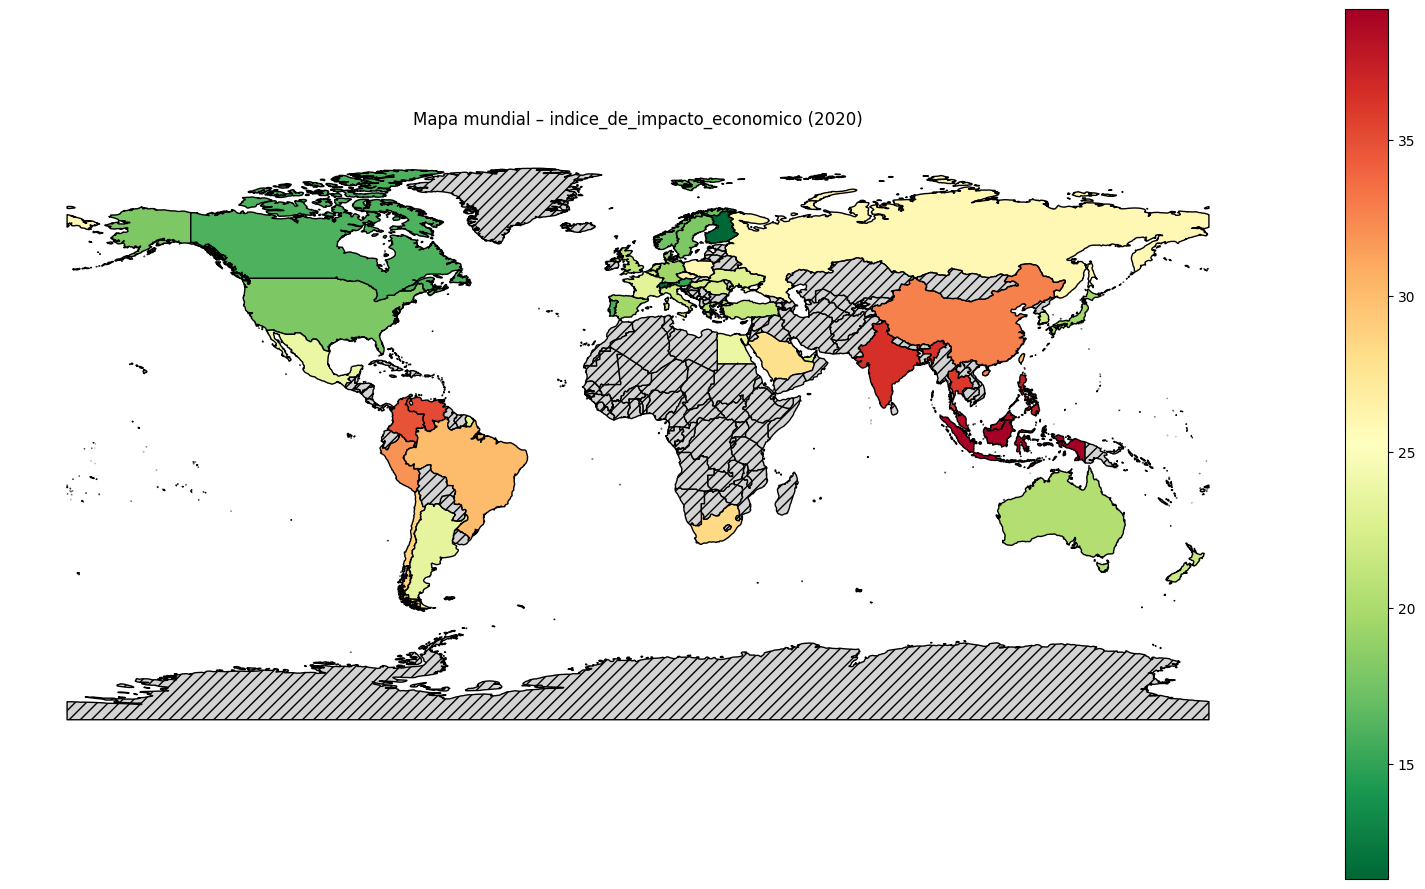

In [1]:
import os
import pandas as pd
import pymysql
import geopandas as gpd
import matplotlib.pyplot as plt
import pycountry
from dotenv import load_dotenv

# ========== Conexión ==========
load_dotenv()
conn = pymysql.connect(
    host=os.getenv('DB_HOST'),
    user=os.getenv('DB_USER'),
    password=os.getenv('DB_PASSWORD'),
    database=os.getenv('DB_NAME')
)

# ========== Parámetros ==========
SHAPEFILE = "./../../data/visualizacion/ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp"

# Indicador a graficar (ejemplo: riesgo_cronico_impacto_en_pib)
INDICADOR_CODE = "indice_de_impacto_economico"

# ========== Query ==========
query = f"""
SELECT 
    h.anio,
    p.codigo AS iso2,
    p.nombre AS pais_nombre,
    i.codigo AS indicador_codigo,
    h.valor AS valor
FROM hechos h
JOIN paises p      ON p.codigo = h.pais_id
JOIN indicadores i ON i.id = h.indicador_id
WHERE i.codigo = '{INDICADOR_CODE}'
"""
df = pd.read_sql(query, conn)

# ISO2 -> ISO3
def iso2_to_iso3(code):
    try:
        return pycountry.countries.get(alpha_2=code).alpha_3
    except:
        return None

df["iso_a3"] = df["iso2"].apply(iso2_to_iso3)
df = df.dropna(subset=["iso_a3"])

# ========== Shapefile ==========
world = gpd.read_file(SHAPEFILE)
shape_key_candidates = ["ADM0_A3", "ISO_A3_EH", "ISO_A3"]
for k in shape_key_candidates:
    if k in world.columns:
        shape_key = k
        break
world[shape_key] = world[shape_key].astype(str).str.upper()

map_data = world.merge(df, left_on=shape_key, right_on="iso_a3", how="left")

# ========== Plot ==========
fig, ax = plt.subplots(figsize=(16, 9))
ax.set_title(f"Mapa mundial – {INDICADOR_CODE} ({df['anio'].max()})", pad=12)

map_data.plot(
    column="valor",
    legend=True,
    ax=ax,
    edgecolor="black",
    cmap="RdYlGn_r",
    missing_kwds={"color": "lightgrey", "hatch": "///", "label": "Sin datos"}
)

ax.axis("off")
plt.tight_layout()
plt.show()